In [1]:
from model_environment import BeachMap, sim_properties

In [2]:
bm = BeachMap()

In [3]:
sim_properties

{'beach': {'color': 'sandybrown'},
 'water': {'color': 'steelblue'},
 'person_to_rescue': {'color': 'red'},
 'base': {'color': 'black'},
 'rescue_location': {'color': 'pink'}}

In [4]:
from model_environment import BeachMap, BeachEnvironment, sim_properties
from drone import BeachAircraft
import fmdtools.sim.propagate as prop

be = BeachEnvironment()
drone = BeachAircraft()

result, hist = prop.nominal(drone)

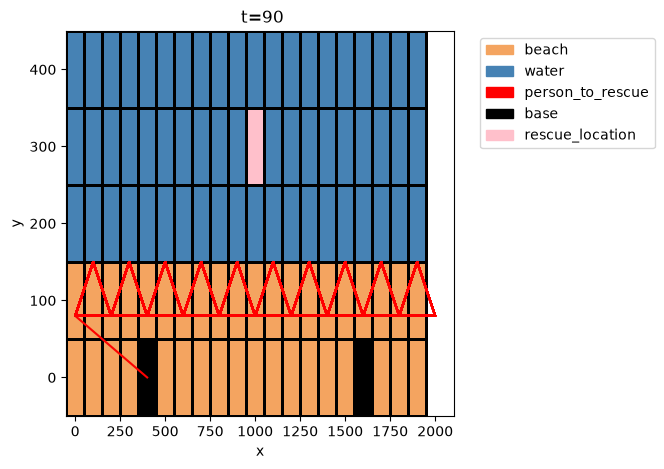

In [5]:
from model_environment import BeachMap, BeachEnvironment, sim_properties
from drone import BeachAircraft
import fmdtools.sim.propagate as prop

be = BeachEnvironment()
drone = BeachAircraft(environment=be, track="all",
                       sp={'end_time': 10000, 'dt': 1.0})

result, hist = prop.nominal(drone, protect=False)

fig, ax = drone.environment.c.show_from(
    90, hist.environment.c, properties=sim_properties
)
hist.plot_trajectory('s.x', 's.y', fig=fig, ax=ax, mark_time=False, time_ticks=200.0, color='red')

(False, None)
(False, None)
(False, None)


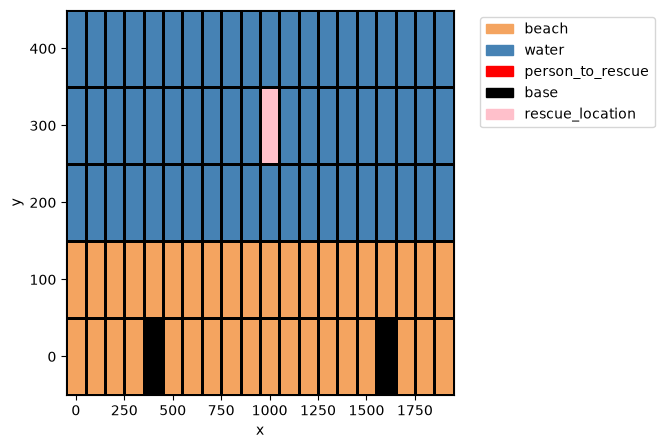

In [6]:
from model_environment import BeachMap, sim_properties
bm = BeachMap()

bm.show(properties=sim_properties)

print(bm.check_vicinity((4000.0, 2000.0)))  # exactly at the victim's location -> True
print(bm.check_vicinity((4200.0, 2000.0)))  # 200m away, inside the 250m radius -> True
print(bm.check_vicinity((0, 0)))            # way outside the radius -> False


(np.float64(1275.6970294559592), np.float64(132.9879206191715))


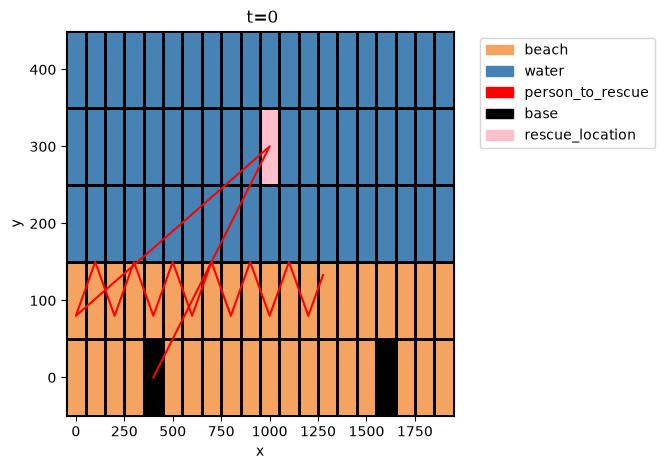

In [7]:
from model_environment import BeachMap, BeachEnvironment, sim_properties
from drone import BeachAircraft
import fmdtools.sim.propagate as prop

be = BeachEnvironment()
drone = BeachAircraft(environment=be, track="all",
                       sp={'end_time': 500, 'dt': 1.0})
drone.set_rescue_goal()   # send the drone to the person in distress

result, hist = prop.nominal(drone, protect=False)
print(tuple(drone.s.get_loc()))  # reached the victim -> (4000.0, 2000.0)

fig, ax = drone.environment.c.show_from(
    0, hist.environment.c, properties=sim_properties
)
hist.plot_trajectory('s.x', 's.y', fig=fig, ax=ax, mark_time=False, time_ticks=500.0, color='red')

None
t=   0  ->  patrol
t= 230  ->  rescue
t= 260  ->  patrol


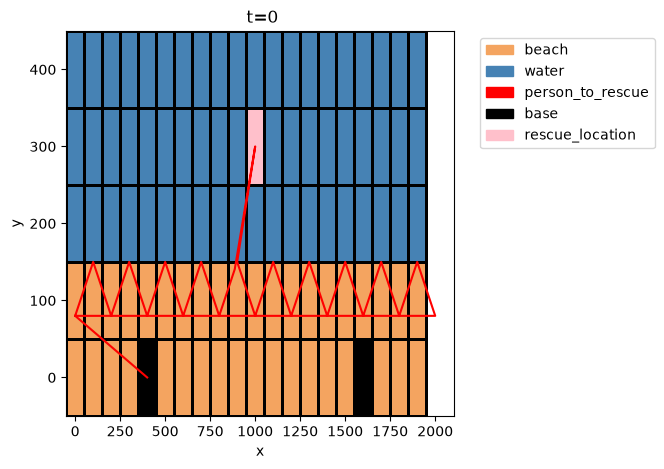

In [8]:
from model_main import Beach
from model_environment import sim_properties
import fmdtools.sim.propagate as prop

# full architecture: BeachBehavior spawns the victim at distress_time,
# drone patrols -> spots them -> rescues -> returns to patrol
mdl = Beach(sp={'end_time': 800, 'dt': 1.0}, track="all")
result, hist = prop.nominal(mdl, protect=False)

# watch the mode switch
prev = None
for t, m in zip(hist.time, hist.fxns.beach_aircraft.m.mode):
    if m != prev:
        print(f"t={t:>4.0f}  ->  {m}")
        prev = m

# map + flight path (patrol zigzag, then the rescue detour)
fig, ax = mdl.flows['environment'].c.show_from(
    0, hist.flows.environment.c, properties=sim_properties
)
hist.plot_trajectory('fxns.beach_aircraft.s.x', 'fxns.beach_aircraft.s.y',
                     fig=fig, ax=ax, mark_time=False, time_ticks=200.0, color='red')
